Cover opened: True
Stego opened: True
Cover frames: 91
Stego frames: 91
Processed frames: 91


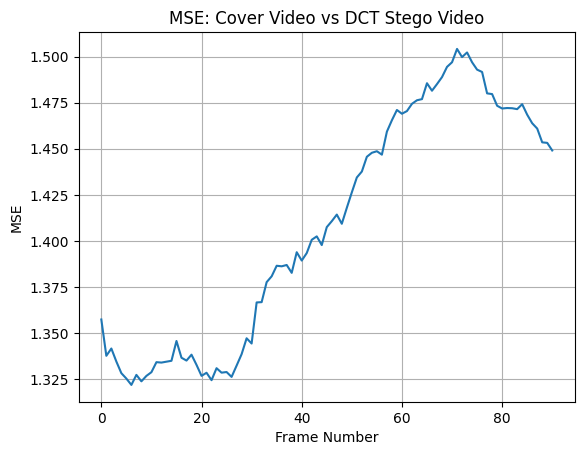

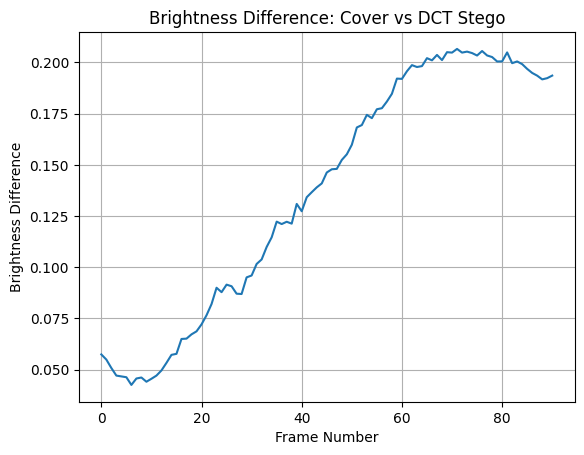

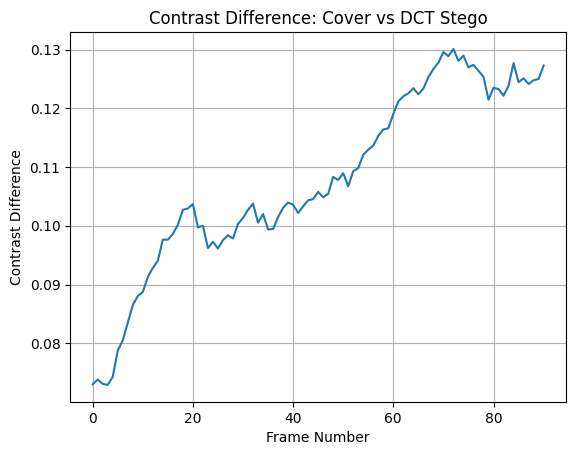

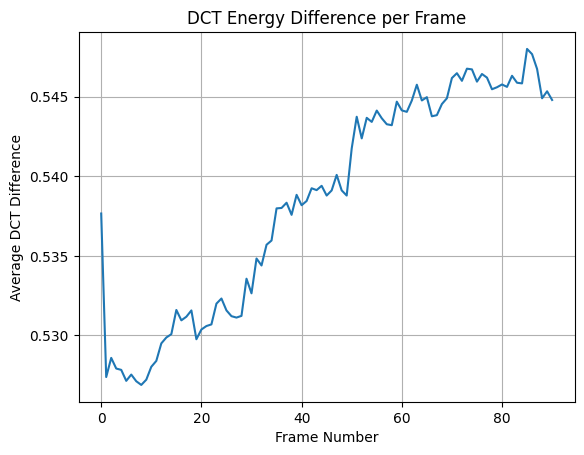

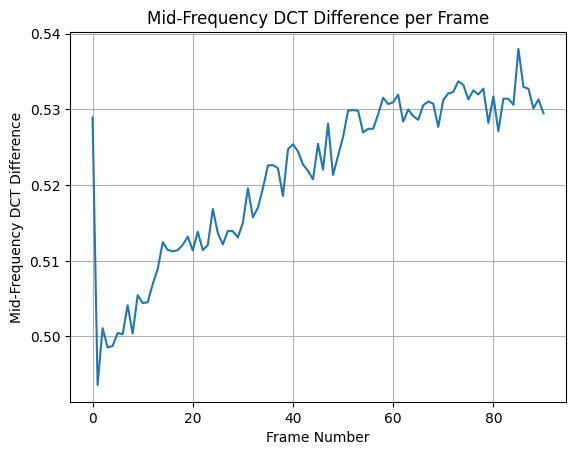

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

cover_path = r"C:\Users\yasse\Downloads\data\data\input\cover_video.mp4"
stego_path = r"C:\Users\yasse\Downloads\data\data\output\stego_video.avi"

cover_cap = cv2.VideoCapture(cover_path)
stego_cap = cv2.VideoCapture(stego_path)

print("Cover opened:", cover_cap.isOpened())
print("Stego opened:", stego_cap.isOpened())
print("Cover frames:", int(cover_cap.get(cv2.CAP_PROP_FRAME_COUNT)))
print("Stego frames:", int(stego_cap.get(cv2.CAP_PROP_FRAME_COUNT)))

if not cover_cap.isOpened():
    raise Exception("Cover video did not open. Check path or filename.")

if not stego_cap.isOpened():
    raise Exception("Stego video did not open. Check path or filename.")

frame_numbers = []

mse_values = []
brightness_diff_values = []
contrast_diff_values = []
dct_energy_diff_values = []
dct_mid_frequency_diff_values = []

frame_index = 0

while True:
    ret1, cover_frame = cover_cap.read()
    ret2, stego_frame = stego_cap.read()

    if not ret1 or not ret2:
        break

    # Make sure both frames have the same size
    if cover_frame.shape != stego_frame.shape:
        stego_frame = cv2.resize(stego_frame, (cover_frame.shape[1], cover_frame.shape[0]))

    cover_gray = cv2.cvtColor(cover_frame, cv2.COLOR_BGR2GRAY)
    stego_gray = cv2.cvtColor(stego_frame, cv2.COLOR_BGR2GRAY)

    # MSE
    mse = np.mean((cover_gray.astype(float) - stego_gray.astype(float)) ** 2)

    # Brightness and contrast differences
    brightness_diff = abs(np.mean(cover_gray) - np.mean(stego_gray))
    contrast_diff = abs(np.std(cover_gray) - np.std(stego_gray))

    # DCT comparison
    cover_float = np.float32(cover_gray)
    stego_float = np.float32(stego_gray)

    cover_dct = cv2.dct(cover_float)
    stego_dct = cv2.dct(stego_float)

    dct_diff = np.abs(cover_dct - stego_dct)

    # Overall DCT energy difference
    dct_energy_diff = np.mean(dct_diff)

    # Mid-frequency DCT region
    # DCT steganography usually hides data in mid-frequency coefficients
    h, w = dct_diff.shape
    mid_region = dct_diff[h//4:h//2, w//4:w//2]
    mid_frequency_diff = np.mean(mid_region)

    frame_numbers.append(frame_index)
    mse_values.append(mse)
    brightness_diff_values.append(brightness_diff)
    contrast_diff_values.append(contrast_diff)
    dct_energy_diff_values.append(dct_energy_diff)
    dct_mid_frequency_diff_values.append(mid_frequency_diff)

    frame_index += 1

cover_cap.release()
stego_cap.release()

print("Processed frames:", len(frame_numbers))

plt.figure()
plt.plot(frame_numbers, mse_values)
plt.title("MSE: Cover Video vs DCT Stego Video")
plt.xlabel("Frame Number")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(frame_numbers, brightness_diff_values)
plt.title("Brightness Difference: Cover vs DCT Stego")
plt.xlabel("Frame Number")
plt.ylabel("Brightness Difference")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(frame_numbers, contrast_diff_values)
plt.title("Contrast Difference: Cover vs DCT Stego")
plt.xlabel("Frame Number")
plt.ylabel("Contrast Difference")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(frame_numbers, dct_energy_diff_values)
plt.title("DCT Energy Difference per Frame")
plt.xlabel("Frame Number")
plt.ylabel("Average DCT Difference")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(frame_numbers, dct_mid_frequency_diff_values)
plt.title("Mid-Frequency DCT Difference per Frame")
plt.xlabel("Frame Number")
plt.ylabel("Mid-Frequency DCT Difference")
plt.grid(True)
plt.show()